In [1]:
# importing important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# importing csv file(our datasets)
HR= pd.read_csv("HR_comma_sep.csv")

In [3]:
HR

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [4]:
HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


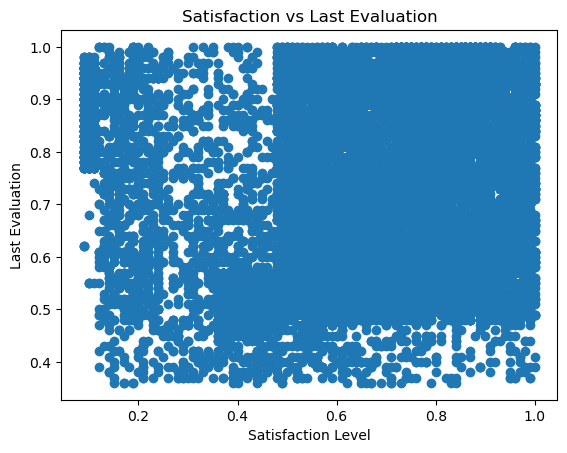

In [5]:
# visualizing (our datasets)
plt.scatter(
    HR['satisfaction_level'],
    HR['last_evaluation']
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.title("Satisfaction vs Last Evaluation")
plt.show()

In [6]:
# checking missing values (data cleaning)
HR.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [7]:
# checking for duplicates (data cleaning)
print(HR.duplicated().sum())

3008


In [8]:
# removing duplicates (data cleaning)
HR = HR.drop_duplicates()

In [9]:
print(HR.shape)

(11991, 10)


In [10]:
HR.rename(columns={
    'average_montly_hours':'average_monthly_hours'
}, inplace=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_19268\1749993069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HR.rename(columns={


In [11]:
HR.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [12]:
# View unique values
print(HR['Department'].unique())
print(HR['salary'].unique())

['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']
['low' 'medium' 'high']


In [13]:
# categoricalling
HR = pd.get_dummies(
    HR,
    columns=['Department','salary'],
    drop_first=True
)

In [14]:
# visualizing
HR.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [15]:
# categoricalling(data transformation, feature engineering)
def satisfaction_level(x):
    if x < 0.4:
        return "Low"
    elif x < 0.7:
        return "Medium"
    else:
        return "High"
HR['satisfaction_category'] = HR['satisfaction_level'].apply(
    satisfaction_level
)

In [16]:
HR = pd.get_dummies(
    HR,
    columns=['satisfaction_category'],
    drop_first=True
)

In [17]:
# combining projects and hours
HR['workload_score'] = (
    HR['number_project'] *
    HR['average_monthly_hours']
)
HR[['number_project',
    'average_monthly_hours',
    'workload_score']].head()

,number_project,average_monthly_hours,workload_score
0,2,157,314
1,5,262,1310
2,7,272,1904
3,5,223,1115
4,2,159,318


In [18]:
# creates promotion indicator
HR['has_promotion'] = HR['promotion_last_5years'].apply(
    lambda x: 1 if x == 1 else 0
)

In [19]:
X = HR.drop('left', axis=1)

y = HR['left']

In [73]:
# preprocessing(feature scaling)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,...,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium,satisfaction_category_Low,satisfaction_category_Medium,workload_score,has_promotion
0,-1.035668,-1.108990,-1.549921,-0.892208,-0.274291,-0.427116,-0.131228,-0.247855,-0.233704,-0.229708,...,-0.246335,1.643797,-0.42315,-0.479817,1.043563,-0.884151,2.200811,-0.778927,-1.317038,-0.131228
1,0.706637,0.851380,1.029194,1.262709,1.981036,-0.427116,-0.131228,-0.247855,-0.233704,-0.229708,...,-0.246335,1.643797,-0.42315,-0.479817,-0.958255,1.131028,-0.454378,-0.778927,1.490925,-0.131228
2,-2.155721,0.970190,2.748604,1.467939,0.477485,-0.427116,-0.131228,-0.247855,-0.233704,-0.229708,...,-0.246335,1.643797,-0.42315,-0.479817,-0.958255,1.131028,2.200811,-0.778927,3.165554,-0.131228
3,0.374770,0.910785,1.029194,0.462311,1.229261,-0.427116,-0.131228,-0.247855,-0.233704,-0.229708,...,-0.246335,1.643797,-0.42315,-0.479817,1.043563,-0.884151,-0.454378,-0.778927,0.941173,-0.131228
4,-1.077151,-1.168396,-1.549921,-0.851162,-0.274291,-0.427116,-0.131228,-0.247855,-0.233704,-0.229708,...,-0.246335,1.643797,-0.42315,-0.479817,1.043563,-0.884151,2.200811,-0.778927,-1.305761,-0.131228


In [74]:
# spilting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(9592, 22)
(2399, 22)


In [75]:
# classifications
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [76]:
# metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [77]:
# logisticRegression
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_prediction = lr.predict(X_test)


In [78]:
# DecisionTree
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_prediction = dt.predict(X_test)

In [79]:
# RandomForest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_prediction = rf.predict(X_test)

In [80]:
# SVM
svm = SVC()

svm.fit(
    X_train,
    y_train
)

svm_prediction = svm.predict(X_test)

In [81]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_prediction = gb.predict(X_test)

In [82]:
# Results(comparing models)
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Gradient Boosting"
    ],

"Accuracy":[
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, rf_prediction),
        accuracy_score(y_test, svm_prediction),
        accuracy_score(y_test, gb_prediction)
    ],

    "Precision":[
        precision_score(y_test, lr_prediction),
        precision_score(y_test, dt_prediction),
        precision_score(y_test, rf_prediction),
        precision_score(y_test, svm_prediction),
        precision_score(y_test, gb_prediction)
    ],

    "Recall":[
        recall_score(y_test, lr_prediction),
        recall_score(y_test, dt_prediction),
        recall_score(y_test, rf_prediction),
        recall_score(y_test, svm_prediction),
        recall_score(y_test, gb_prediction)
    ],

    "F1 Score":[
        f1_score(y_test, lr_prediction),
        f1_score(y_test, dt_prediction),
        f1_score(y_test, rf_prediction),
        f1_score(y_test, svm_prediction),
        f1_score(y_test, gb_prediction)
    ]
})


results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.900375,0.762987,0.586035,0.662906
1,Decision Tree,0.965819,0.895782,0.900249,0.898010
2,Random Forest,0.978741,0.978142,0.892768,0.933507
3,SVM,0.957065,0.870647,0.872818,0.871731
4,Gradient Boosting,0.977074,0.960106,0.900249,0.929215


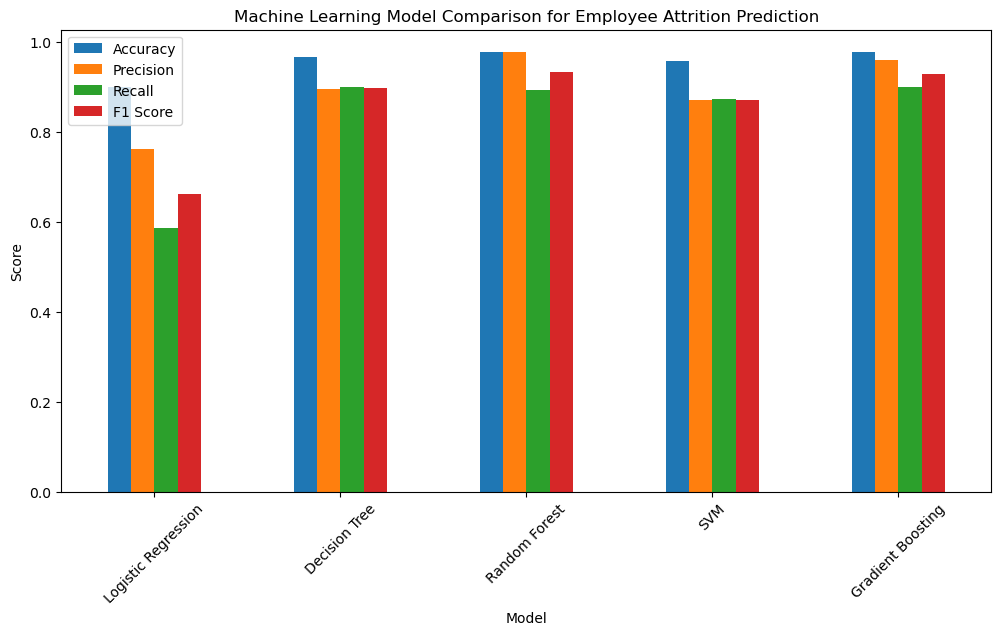

In [83]:
# Visualizing (comparing models)
results.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Machine Learning Model Comparison for Employee Attrition Prediction"
)

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

In [84]:
# evaluating (random forest)
print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.98      0.89      0.93       401

    accuracy                           0.98      2399
   macro avg       0.98      0.94      0.96      2399
weighted avg       0.98      0.98      0.98      2399



In [85]:
# confusion matrix (random forest)
cm = confusion_matrix(
    y_test,
    rf_prediction
)

print(cm)

[[1990    8]
 [  43  358]]


In [86]:
from sklearn.model_selection import GridSearchCV

In [87]:
# paremeter grid (decision tree)
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [88]:
# gridsearch(decision tree)
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best Cross Validation Score:", dt_grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross Validation Score: 0.983527982346558


In [89]:
# evaluating tuned model(decision tree)
best_dt = dt_grid.best_estimator_

dt_pred = best_dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print(classification_report(
    y_test,
    dt_pred
))

Accuracy: 0.9787411421425594
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1998
           1       0.97      0.90      0.93       401

    accuracy                           0.98      2399
   macro avg       0.98      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399



In [90]:
# paremeter grid (random forest)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [91]:
# gridsearch(random forest)
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Score: 0.9846749018241926


Accuracy: 0.9787411421425594
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.98      0.89      0.93       401

    accuracy                           0.98      2399
   macro avg       0.98      0.94      0.96      2399
weighted avg       0.98      0.98      0.98      2399



In [40]:
# paremeter grid (svm)
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

In [41]:
# gridsearch(svm)
svm_grid = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best Score:", svm_grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Score: 0.9644491368625365


In [42]:
# evaluating tuned model(svm)
best_svm = svm_grid.best_estimator_

svm_pred = best_svm.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, svm_pred))

print(classification_report(
    y_test,
    svm_pred
))

Accuracy: 0.9666527719883284
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1998
           1       0.92      0.88      0.90       401

    accuracy                           0.97      2399
   macro avg       0.95      0.93      0.94      2399
weighted avg       0.97      0.97      0.97      2399



In [43]:
# paremeter grid (gradientboosting)
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

In [44]:
# gridsearch(gradientboosting)
gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best Score:", gb_grid.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
Best Score: 0.9853002275146565


In [45]:
# evaluating tuned model(gradientboosting)
best_gb = gb_grid.best_estimator_

gb_pred = best_gb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, gb_pred))

print(classification_report(
    y_test,
    gb_pred
))

Accuracy: 0.9791579824927052
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1998
           1       0.97      0.91      0.94       401

    accuracy                           0.98      2399
   macro avg       0.97      0.95      0.96      2399
weighted avg       0.98      0.98      0.98      2399



In [46]:
# optimized models
results_tuned = pd.DataFrame({
    'Model': [
        'Decision Tree (Tuned)',
        'Random Forest (Tuned)',
        'SVM (Tuned)',
        'Gradient Boosting (Tuned)'
    ],

    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

print(results_tuned.sort_values(
    by='Accuracy',
    ascending=False
))

                       Model  Accuracy
3  Gradient Boosting (Tuned)  0.979158
0      Decision Tree (Tuned)  0.978741
1      Random Forest (Tuned)  0.978741
2                SVM (Tuned)  0.966653


In [47]:
# optimized model(random forest)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                         Feature  Importance
0             satisfaction_level    0.233941
20                workload_score    0.228724
4             time_spend_company    0.148901
2                 number_project    0.114133
3          average_monthly_hours    0.103153
1                last_evaluation    0.100793
18     satisfaction_category_Low    0.030761
19  satisfaction_category_Medium    0.016474
5                  Work_accident    0.005815
16                    salary_low    0.004359


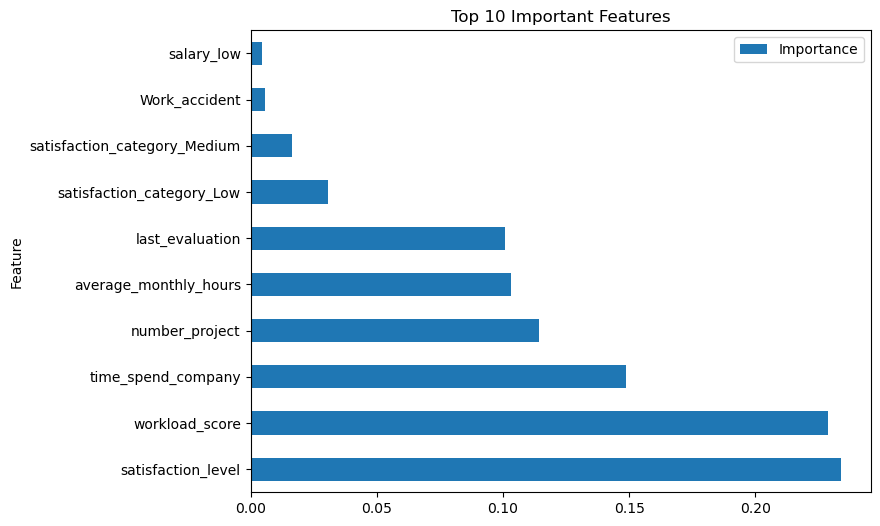

In [48]:
# optimized model visualizating (random forest)
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,6)
)

plt.title("Top 10 Important Features")
plt.show()

In [49]:
# importing additional evaluation metrics
from sklearn.metrics import (
      roc_auc_score,
      RocCurveDisplay
)

In [51]:
# evaluate model(random forest)
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [52]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9787411421425594


In [53]:
# precision 
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9781420765027322


In [54]:
# recall
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.8927680798004988


In [55]:
# f1 score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9335071707953064


In [56]:
# roc auc score
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9755041824867261


In [57]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1990    8]
 [  43  358]]


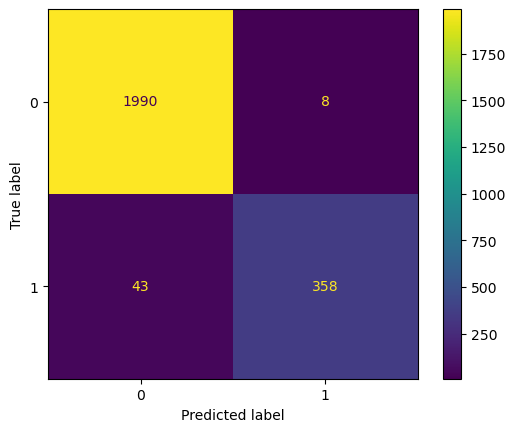

In [59]:
# visualizing
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm).plot()

plt.show()

In [60]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1998
           1       0.98      0.89      0.93       401

    accuracy                           0.98      2399
   macro avg       0.98      0.94      0.96      2399
weighted avg       0.98      0.98      0.98      2399



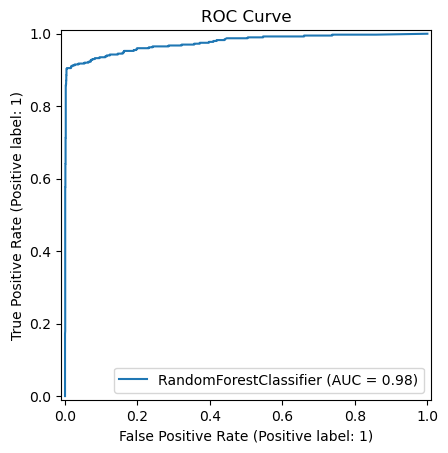

In [61]:
# visualizing classification report
RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [62]:
# comparing metrics across all models
models = {
    "Logistic Regression": lr,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "SVM": best_svm,
    "Gradient Boosting": best_gb
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, prob)
    else:
        auc = None

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        auc
    ])

evaluation_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print(evaluation_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.900375   0.762987  0.586035  0.662906  0.912849
1        Decision Tree  0.978741   0.970430  0.900249  0.934023  0.962327
2        Random Forest  0.978741   0.978142  0.892768  0.933507  0.975504
3                  SVM  0.966653   0.919060  0.877805  0.897959       NaN
4    Gradient Boosting  0.979158   0.968000  0.905237  0.935567  0.978065


In [63]:
# comparison and analysis
from sklearn.model_selection import cross_validate
results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=10,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1',
            'roc_auc'
        ]
    )

    results.append({
        'Model': name,
        'Accuracy Mean': scores['test_accuracy'].mean(),
        'Accuracy Std': scores['test_accuracy'].std(),
        'Precision Mean': scores['test_precision'].mean(),
        'Recall Mean': scores['test_recall'].mean(),
        'F1 Mean': scores['test_f1'].mean(),
        'ROC-AUC Mean': scores['test_roc_auc'].mean()
    })

comparison_df = pd.DataFrame(results)

comparison_df

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.838627,0.064236,0.618947,0.307367,0.402416,0.860226
1,Decision Tree,0.981653,0.003822,0.970571,0.917631,0.943204,0.966574
2,Random Forest,0.983321,0.003399,0.987114,0.911601,0.947753,0.979760
3,SVM,0.941706,0.009875,0.813428,0.844789,0.828228,0.949181
4,Gradient Boosting,0.982820,0.003862,0.974769,0.920643,0.946798,0.982220


In [64]:
# ranking the models
comparison_df.sort_values(
    by='F1 Mean',
    ascending=False
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
2,Random Forest,0.983321,0.003399,0.987114,0.911601,0.947753,0.979760
4,Gradient Boosting,0.982820,0.003862,0.974769,0.920643,0.946798,0.982220
1,Decision Tree,0.981653,0.003822,0.970571,0.917631,0.943204,0.966574
3,SVM,0.941706,0.009875,0.813428,0.844789,0.828228,0.949181
0,Logistic Regression,0.838627,0.064236,0.618947,0.307367,0.402416,0.860226


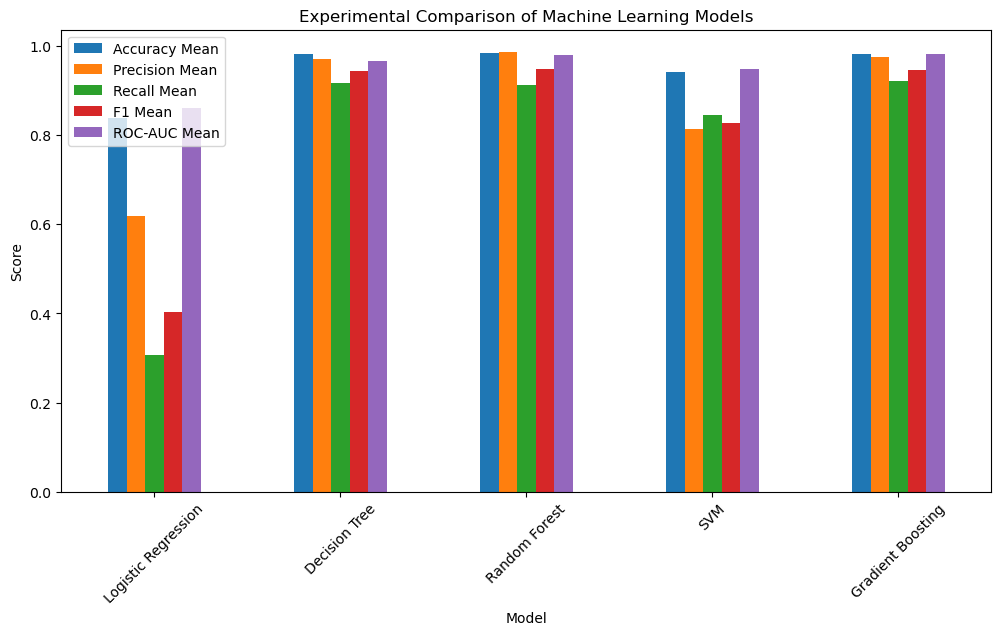

In [65]:
# comparison visualisinng
comparison_df.set_index('Model')[
    ['Accuracy Mean',
     'Precision Mean',
     'Recall Mean',
     'F1 Mean',
     'ROC-AUC Mean']
].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Experimental Comparison of Machine Learning Models')
plt.ylabel('Score')
plt.xticks(rotation=45)

plt.show()

In [66]:
# analysing model stability
stability = comparison_df[
    ['Model',
     'Accuracy Mean',
     'Accuracy Std']
]

print(stability.sort_values(
    by='Accuracy Std'
))

                 Model  Accuracy Mean  Accuracy Std
2        Random Forest       0.983321      0.003399
1        Decision Tree       0.981653      0.003822
4    Gradient Boosting       0.982820      0.003862
3                  SVM       0.941706      0.009875
0  Logistic Regression       0.838627      0.064236


In [67]:
# statistical comparison
from scipy.stats import ttest_rel
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    X,
    y,
    cv=10,
    scoring='f1'
)

lr_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=10,
    scoring='f1'
)

t_stat, p_value = ttest_rel(
    rf_scores,
    lr_scores
)

print("T-statistic:", t_stat)
print("P-value:", p_value)


C:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

T-statistic: 14.766449515529935
P-value: 1.2927260042297228e-07


C:\Users\pc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
# interpretation
if p_value < 0.05:
    print("Significant difference between models")
else:
    print("No significant difference between models")

Significant difference between models


In [69]:
# comparing tuned and untuned models
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [70]:
# evaluate the models
default_rf = RandomForestClassifier(random_state=42)

default_rf.fit(X_train, y_train)

default_pred = default_rf.predict(X_test)

best_pred = best_rf.predict(X_test)

print("Default RF F1:",
      f1_score(y_test, default_pred))

print("Optimized RF F1:",
      f1_score(y_test, best_pred))

Default RF F1: 0.9335071707953064
Optimized RF F1: 0.9362808842652796


In [71]:
# why best model performs well
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                         Feature  Importance
0             satisfaction_level    0.241524
20                workload_score    0.227352
4             time_spend_company    0.142072
1                last_evaluation    0.107450
3          average_monthly_hours    0.102897
2                 number_project    0.102628
18     satisfaction_category_Low    0.026924
19  satisfaction_category_Medium    0.017286
16                    salary_low    0.005557
5                  Work_accident    0.005364


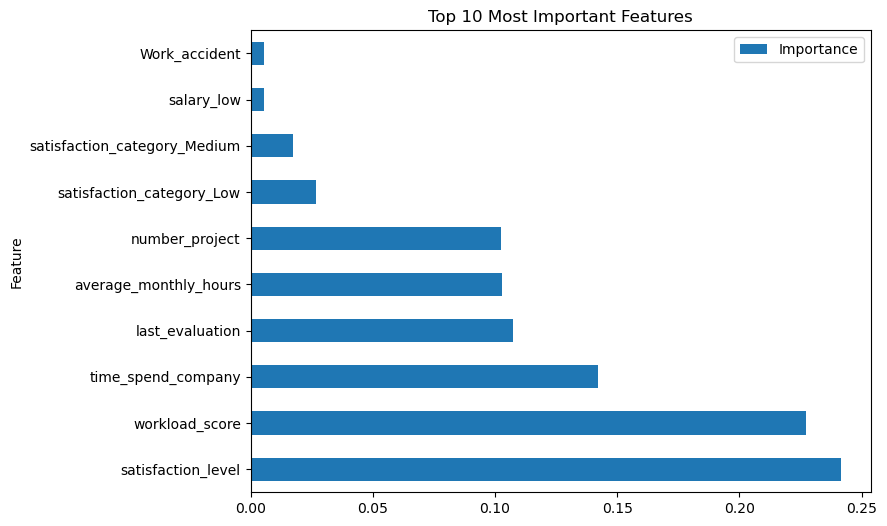

In [72]:
# visualizing
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,6)
)

plt.title('Top 10 Most Important Features')
plt.show()